# QVNTVS: Open-Source Quantum Well Simulator

## Manual #1 

* QVNTVS is an open-source project based in Python for modeling and simulating quantum wells of different shapes and heterojunctions including analyzing energy levels, wavefunctions, recombination probabilities, optical phenomena and more.
* QVNTVS is an original work of Barbaros Şair and conducted as an independent research effort while working as Undergraduate Researcher at UNAM, National Nanotechnology Centre.
* This manual includes a simulation manual for infinite rectangular wells.

## 1-Importing QVNTVS
* Note that to run Qvntvs: NumPy, MatplotLib, and SciPy are needed.
* To find requirements: requirements.txt

In [31]:
from QVTNVS import Qvntvs

## 2-Initialization
* For educational purposes, we will create four entities.
* The first is infinite rectangular well.
* The second is finite rectangular well heterojunction (CdS/CdSe)
* The third is finite multiple rectangular well heterojunction (Cd/CdSe)
* The fourth is finite rectangular well heterojunction (CdS/CdSe) under moderate net-bias
* In this manual, we will cover infinite rectangular well case.

In [32]:
infinite_well = Qvntvs( potential_barrier_electron=10000,  
                        potential_barrier_hole=10000,       
                        band_gap_well=1.84,              
                        m_e_well=1,      
                        m_hh_well=1,      
                        m_lh_well=1,     
                        m_e_barrier=1,   
                        m_hh_barrier=1,
                        m_lh_barrier=1,    
                        biasing_voltage=0.7,         
                        built_in_voltage=0.7,            
                        well_width_nm=5,
                        barrier_width_nm=10,
                        n_wells=1,
                        n_intervals=2000)

## 3-Plotting the Potential Profiles
* Plotting electron and hole potential profiles.

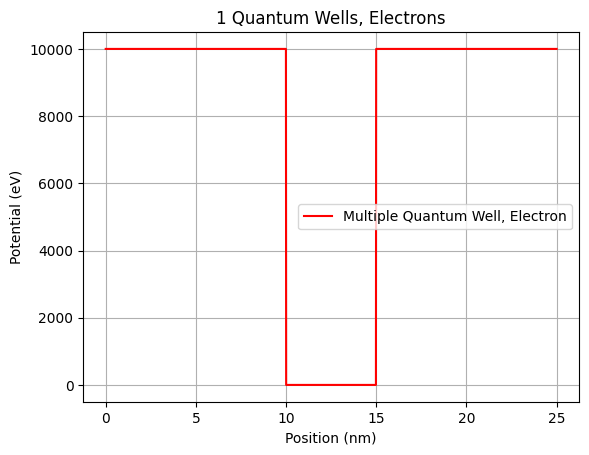

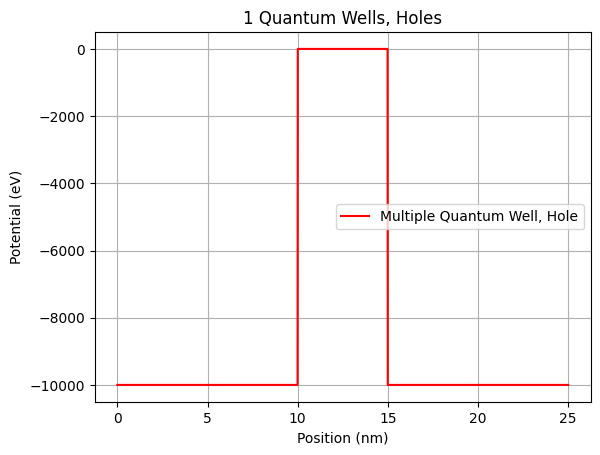

In [33]:
infinite_well_pot_electron = infinite_well.rectangular_potential_profile(electron=True, plot=True)
infinite_well_pot_hole = infinite_well.rectangular_potential_profile(electron=False, plot=True)

## 4- Setting Up the Effective Masses
* Plot and Set the effective masses across the junction.
* Prepare the inverse masses.

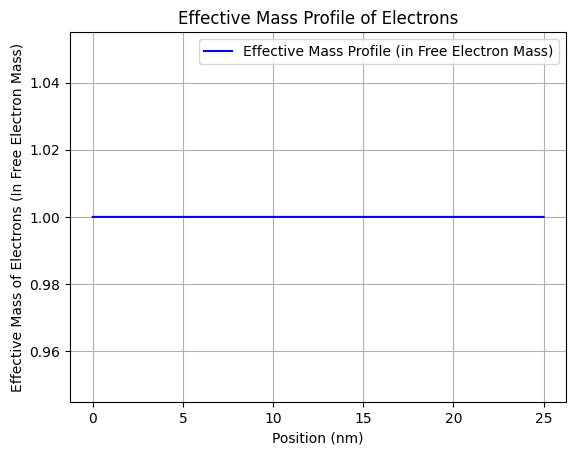

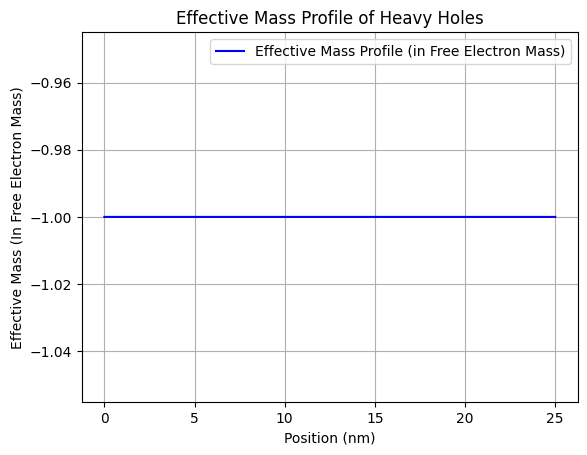

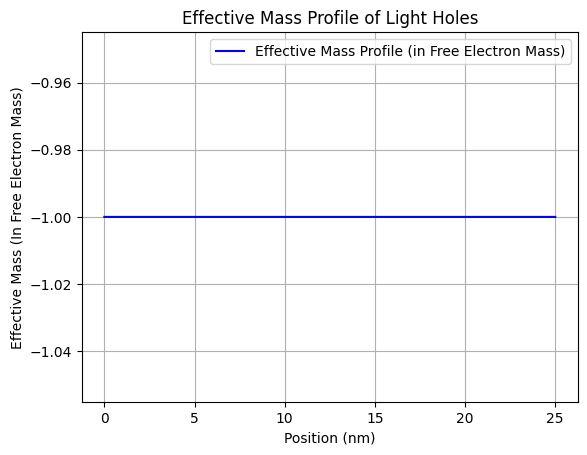

In [34]:
infinite_m_electron, infinite_m_hhole, infinite_m_lhole = infinite_well.effective_mass_profile(plot=True)

infinite_inv_m_hhole = infinite_well.inverse_mass_profile(infinite_m_hhole, plot=False)
infinite_inv_m_lhole = infinite_well.inverse_mass_profile(infinite_m_lhole, plot=False)
infinite_inv_m_electron = infinite_well.inverse_mass_profile(infinite_m_electron, plot=False)

## 5-Defining Hamiltonian Matrix and Solutions
* Setting up the Hamiltonian Matrix.
* Solving Schrödinger Equation and getting energy levels & wavefunctions

In [35]:
H_infinite_electron = infinite_well.hamiltonian_matrix(infinite_well_pot_electron, inv_mass=infinite_inv_m_electron)
H_infinite_hhole = infinite_well.hamiltonian_matrix(infinite_well_pot_hole, inv_mass=infinite_inv_m_hhole)
H_infinite_lhole = infinite_well.hamiltonian_matrix(infinite_well_pot_hole, inv_mass=infinite_inv_m_lhole)

 Electron Energy Level 1: 0.015 eV
 Electron Energy Level 2: 0.060 eV
 Electron Energy Level 3: 0.135 eV
 Electron Energy Level 4: 0.240 eV
 Electron Energy Level 5: 0.376 eV


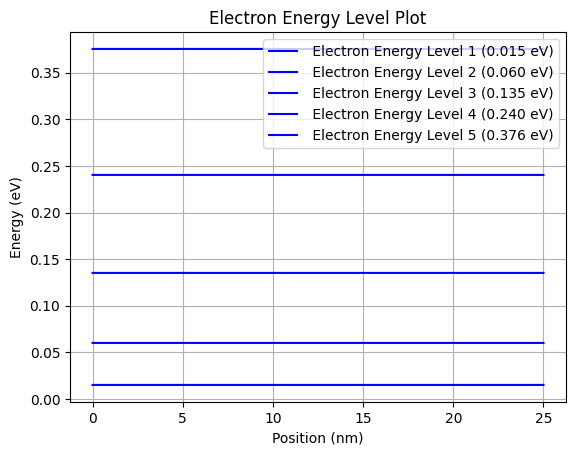

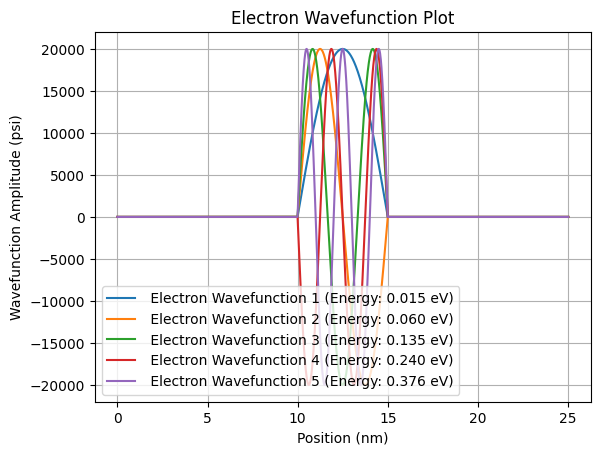

 Heavy Holes Energy Level 1: -0.015 eV
 Heavy Holes Energy Level 2: -0.060 eV
 Heavy Holes Energy Level 3: -0.135 eV
 Heavy Holes Energy Level 4: -0.240 eV
 Heavy Holes Energy Level 5: -0.376 eV


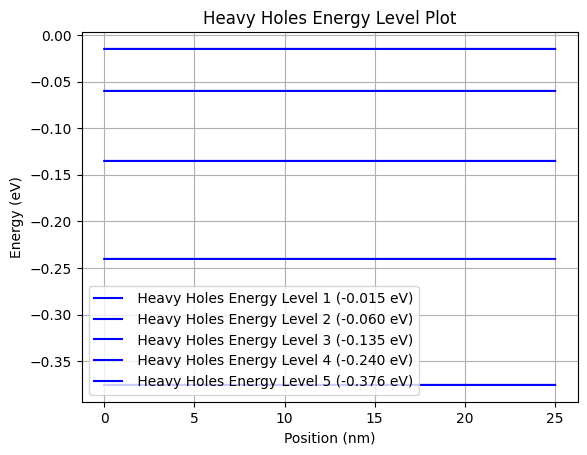

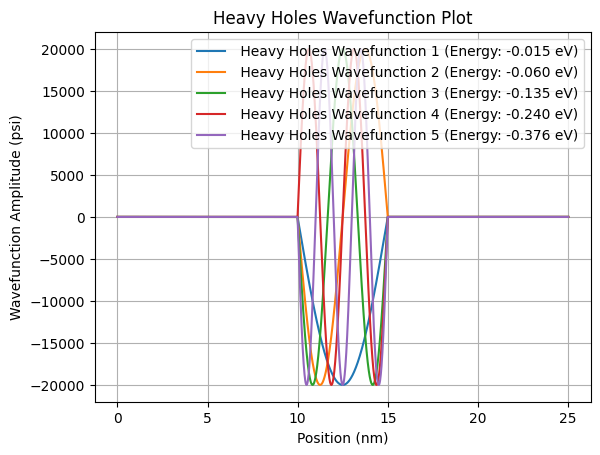

 Light Hole Energy Level 1: -0.015 eV
 Light Hole Energy Level 2: -0.060 eV
 Light Hole Energy Level 3: -0.135 eV
 Light Hole Energy Level 4: -0.240 eV
 Light Hole Energy Level 5: -0.376 eV


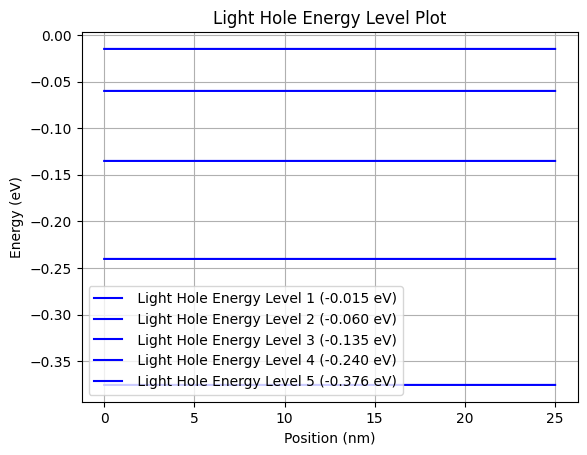

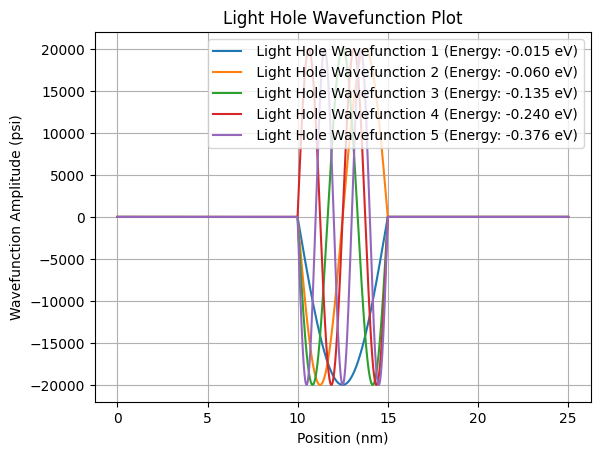

In [37]:
energy_levels_electron, wave_functions_electron = infinite_well.eigen_equation(H_infinite_electron, V_general=infinite_well_pot_electron, electron=True,n_levels=5, plot=True)
energy_levels_hhole, wave_functions_hhole = infinite_well.eigen_equation(H_infinite_hhole, V_general=infinite_well_pot_hole, electron=False, n_levels=5, plot=True)
energy_levels_lhole, wave_functions_lhole = infinite_well.eigen_equation(H_infinite_lhole, V_general=infinite_well_pot_hole, electron=False, heavy_holes=False ,n_levels=5, plot=True)

## 6-Computing the Recombination Probabilities
* Define a matrix that includes all wavefunction overlap combinations.
* Represent the probability of recombinations as a heatmap matrix for visualization.
* The probabilities assume that there is indeed *a particle in the computed state* which may not be the case. Probability of finding a particle in a state depends on multiple parameters such as temperature, optical excitation, et cetera.

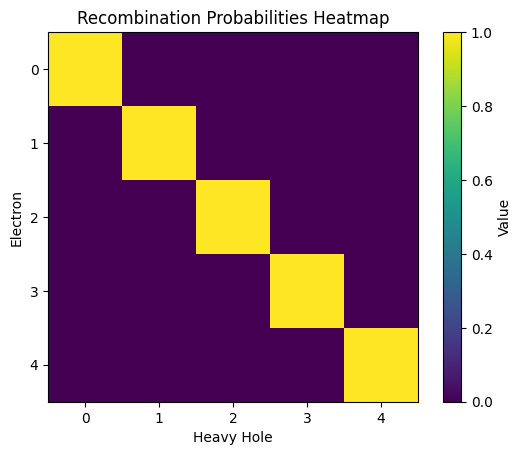

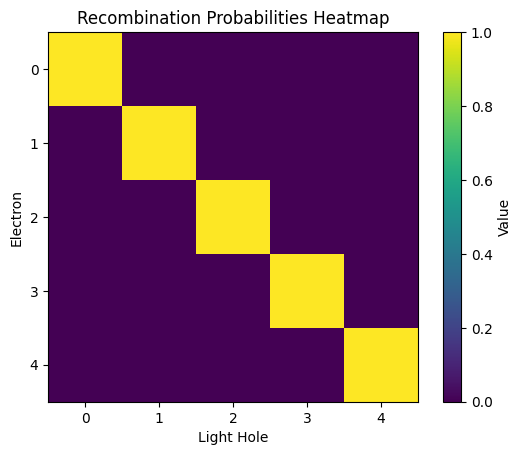

In [38]:
recomb_matrix_ehh = infinite_well.recombination_probability(wave_functions_electron, wave_functions_hhole, plot=True)
recomb_matrix_elh = infinite_well.recombination_probability(wave_functions_electron, wave_functions_lhole,heavy_hole=False, plot=True)

## 7-Computing the Optical Transition Matrix
* Define the matrix including energy and probability information.
* Visualize the matrix as a heatmap.
* List first 3 most probable energy transitions with their probabilities

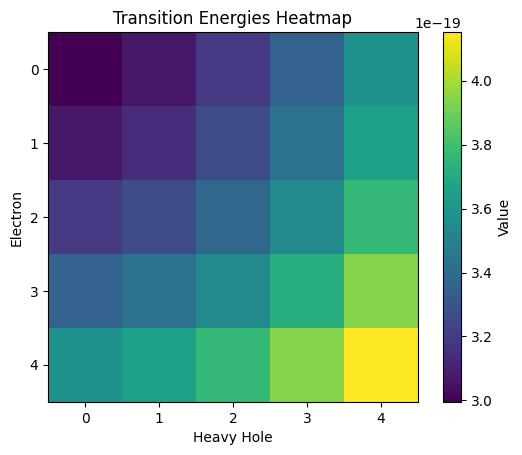

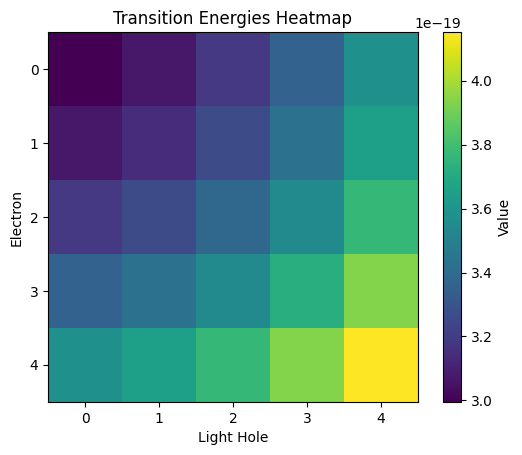

In [39]:
optical_matrix_ehh = infinite_well.transition_energies(energy_levels_electron, recombination_matrix=recomb_matrix_ehh, energy_levels_hole=energy_levels_hhole,plot=True, heavy_hole=True)
optical_matrix_elh = infinite_well.transition_energies(energy_levels_electron, recombination_matrix=recomb_matrix_elh, energy_levels_hole=energy_levels_lhole,plot=True, heavy_hole=False)

In [44]:
for i in range(3):
    print(f"Electron - Heavy Hole Transition Energy:{optical_matrix_ehh[i][0]/1.602176634e-19 :.5f}, Probability: {optical_matrix_ehh[i][1]*100} %")

for i in range(3):
    print(f"Electron - Light Hole Transition Energy:{optical_matrix_elh[i][0]/1.602176634e-19 :.5f}, Probability: {optical_matrix_elh[i][1]*100} %")

Electron - Heavy Hole Transition Energy:2.32068, Probability: 100.00000000000009 %
Electron - Heavy Hole Transition Energy:1.87005, Probability: 100.00000000000004 %
Electron - Heavy Hole Transition Energy:1.96018, Probability: 100.00000000000004 %
Electron - Light Hole Transition Energy:2.32068, Probability: 100.00000000000009 %
Electron - Light Hole Transition Energy:1.87005, Probability: 100.00000000000004 %
Electron - Light Hole Transition Energy:1.96018, Probability: 100.00000000000004 %


## 8-Emission Wavelength Calculation
* Spectral analysis and visualization
* The shorter wavelengths are due to the localization of particles at different extreme points and increasing the transition energies. Though it is shown here at comparable probabilities, in reality the states contributing to this higher transitions may not be living in the junction. Because, the probability of a particle living in a state depends on multiple factors like temperature, excitation et cetera.
* As a result, shorter wavelengths and higher transition energies may not be good approximations. 

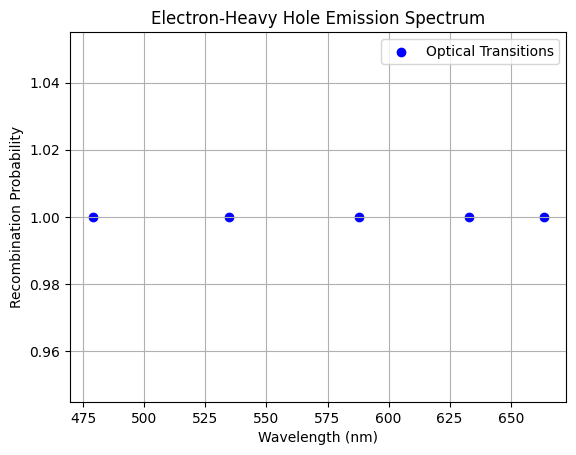

Transition 1: Wavelength = 534.63 nm, Probability = 100.00%
Transition 2: Wavelength = 663.46 nm, Probability = 100.00%
Transition 3: Wavelength = 632.95 nm, Probability = 100.00%
Transition 4: Wavelength = 478.84 nm, Probability = 100.00%
Transition 5: Wavelength = 587.90 nm, Probability = 100.00%


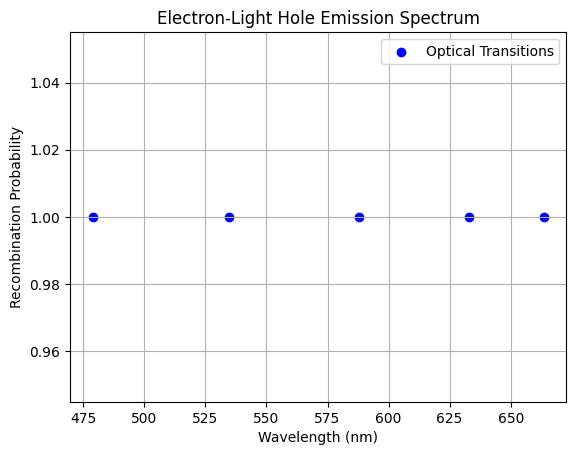

Transition 1: Wavelength = 534.63 nm, Probability = 100.00%
Transition 2: Wavelength = 663.46 nm, Probability = 100.00%
Transition 3: Wavelength = 632.95 nm, Probability = 100.00%
Transition 4: Wavelength = 478.84 nm, Probability = 100.00%
Transition 5: Wavelength = 587.90 nm, Probability = 100.00%


In [45]:
optical_char = infinite_well.optical_char(optical_matrix_ehh)
optical_char = infinite_well.optical_char(optical_matrix_elh, heavy_hole=False)